# 第七次课后练习


<span style="color:red; font-weight:bold;">请将作业文件命名为 第七次课后练习+姓名+学号.ipynb, 不用提交数据环境，但需要保留运行结果。例如 第七次课后练习+张三+1000000000.ipynb</span>

<span style="color:red; font-weight:bold;">在作业过程中觉得有心得或者自己拓展学习到有价值内容的，可以在文件名最后加一个#号。例如第七次课后练习+张三+1000000000+#.ipynb</span>

本次作业给出了一个完整的项目环境：数据准备-数据分析（可视化，降维）-聚类-结果评估

在每个步骤后给出对应的练习。请先认真阅读理解代码，然后按要求完成练习。

### 手写体数据处理及聚类分析

第一步：导入数据

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 加载手写体数字图片及标签数据mnist
trainData = pd.read_csv('train_X.csv')  # 读入图片像素数据
label = pd.read_csv('train_Y.csv')      # 标签数据 0-9

In [2]:
trainData # pandas数据表形式，每行一个图片-784像素（28*28）

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
69998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
label

,class
0,5
1,0
2,4
3,1
4,9
...,...
69995,2
69996,3
69997,4
69998,5


In [4]:
X = np.array(trainData)
y = np.array(label)

X = X[:6000, :] # 本次作业环境取前6000个样本
y = y[:6000, :]

(X.shape, y.shape)

((6000, 784), (6000, 1))

In [5]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [6]:
y[0:10]

array([[5],
       [0],
       [4],
       [1],
       [9],
       [2],
       [1],
       [3],
       [1],
       [4]], dtype=int64)

In [ ]:
# 练习1：
# 请你把矩阵y重新变换成一个[6000，]的一维矩阵y_1，然后从y_1再生成与y相同的y_2，
# 要求三个矩阵y和y_1不独立，y_1和y_2独立
# your code：

# y_1: 使用ravel()返回视图，与y共享内存（不独立）
y_1 = y.ravel()  # shape: (6000,)

# y_2: 使用copy()创建独立副本后reshape为与y相同形状
y_2 = y_1.copy().reshape(-1, 1)  # shape: (6000, 1)

# 验证
print(f"y shape: {y.shape}, y_1 shape: {y_1.shape}, y_2 shape: {y_2.shape}")
print(f"y和y_1共享内存（不独立）: {np.shares_memory(y, y_1)}")
print(f"y_1和y_2独立（不共享内存）: {not np.shares_memory(y_1, y_2)}")
print(f"y_2与y内容相同: {np.array_equal(y, y_2)}")

**第二步 使用plt查看图像, 使用plt.imshow函数打印图像，图像reshape为(28, 28)。使用了subplot(),**

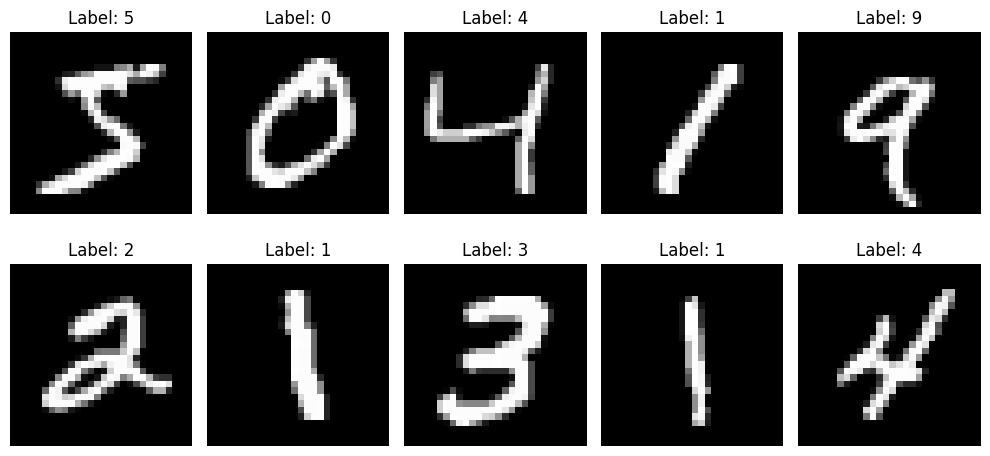

In [8]:
import matplotlib.pyplot as plt

# 显示前10张图片
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(10):
    row = i // 5  # 每行显示5个数字图片
    col = i % 5
    img = X[i].reshape(28, 28)
    axes[row, col].imshow(img, cmap='gray')
    axes[row, col].set_title(f'Label: {y[i][0]}')  # 如果y是(6000,1)格式
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 练习2：
# 请你将所有的数字相同的图片叠加求平均，然后显示10个平均后的图像
# your code：

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for digit in range(10):
    row = digit // 5
    col = digit % 5
    mask = (y.ravel() == digit)
    avg_img = X[mask].mean(axis=0).reshape(28, 28)
    axes[row, col].imshow(avg_img, cmap='gray')
    axes[row, col].set_title(f'Digit: {digit} (n={mask.sum()})')
    axes[row, col].axis('off')
plt.suptitle('Average Image of Each Digit (0-9)')
plt.tight_layout()
plt.show()

计算协方差矩阵

In [10]:
# 中心化：减去均值
mean = np.mean(X, axis=0)  # 计算每个特征的均值 (784,)
X_centered = X - mean  # 中心化后的数据 (6000, 784)

# 方法1：使用矩阵乘法计算协方差矩阵
# 公式：C = (1/(n-1)) * X_centered.T @ X_centered
cov_matrix = (X_centered.T @ X_centered) / (X_centered.shape[0] - 1)

print(f"协方差矩阵形状: {cov_matrix.shape}")  # (784, 784)

# 方法2：使用 numpy 内置函数验证
cov_matrix_check = np.cov(X, rowvar=False)  # rowvar=False 表示每列是一个特征
print(f"结果是否一致: {np.allclose(cov_matrix, cov_matrix_check)}")

协方差矩阵形状: (784, 784)
结果是否一致: True


In [11]:
cov_matrix

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

问：这个协方差矩阵对角线元素为0，合理吗？

deepseek：协方差矩阵对角线元素为0 不合理！
对角线元素代表方差，如果为0说明该特征在所有样本中取值完全相同（没有变化），这在真实数据中很少见，通常是数据有问题。

选做题：请你沿着这个问题，分析为什么会出现这种情况，可能导致的后果，以及类似情况下合理的数据处理方案。


In [ ]:
# 选做题：分析协方差矩阵对角线为0的原因、后果及处理方案

# ===== 原因分析 =====
# 手写数字图像的边缘像素在所有样本中始终为0（数字不会写到图片边缘），
# 因此这些像素的方差为0，导致协方差矩阵对角线对应位置为0。
# 这是合理的！并非数据有问题，而是图像本身的特性。

zero_var_count = np.sum(np.diag(cov_matrix) == 0)
nonzero_var_count = np.sum(np.diag(cov_matrix) > 0)
print(f"零方差特征数: {zero_var_count}, 非零方差特征数: {nonzero_var_count}")
print(f"零方差特征占比: {zero_var_count / 784:.2%}")

# 可视化哪些像素方差为0
var_map = np.diag(cov_matrix).reshape(28, 28)
plt.figure(figsize=(6, 5))
plt.imshow(var_map, cmap='hot')
plt.colorbar(label='Variance')
plt.title('Pixel Variance Map\n(黑色=零方差，即边缘像素)')
plt.show()

# ===== 后果 =====
# 1. 零方差特征不提供任何判别信息，增加不必要的计算开销
# 2. 协方差矩阵奇异（不可逆），影响某些需要求逆的算法
# 3. PCA中这些特征对应的特征值为0，浪费计算资源

# ===== 处理方案：去除零方差特征 =====
nonzero_mask = np.diag(cov_matrix) > 0
X_filtered = X[:, nonzero_mask]
print(f"\n去除零方差特征后: {X.shape[1]} → {X_filtered.shape[1]} 维")
print(f"数据压缩率: {1 - X_filtered.shape[1] / X.shape[1]:.2%}")

# 对比效果：去除零方差特征后PCA+KMeans
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix
import time

y_flat = y.ravel() if y.ndim > 1 else y

# 原始数据 PCA+KMeans
t0 = time.time()
pca_orig = PCA(n_components=20, random_state=42)
X_pca_orig = pca_orig.fit_transform(X)
km_orig = KMeans(n_clusters=10, random_state=42, n_init=10).fit(X_pca_orig)
t_orig = time.time() - t0

# 过滤后数据 PCA+KMeans
t0 = time.time()
pca_filt = PCA(n_components=20, random_state=42)
X_pca_filt = pca_filt.fit_transform(X_filtered)
km_filt = KMeans(n_clusters=10, random_state=42, n_init=10).fit(X_pca_filt)
t_filt = time.time() - t0

# 计算准确率
def calc_acc(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=range(10))
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}
    return np.mean(np.array([mapping[l] for l in y_pred]) == y_true)

acc_orig = calc_acc(y_flat, km_orig.labels_)
acc_filt = calc_acc(y_flat, km_filt.labels_)

print(f"\n===== 对比结果 =====")
print(f"原始数据(784维): 准确率={acc_orig:.4f}, 耗时={t_orig:.3f}s")
print(f"过滤后({X_filtered.shape[1]}维): 准确率={acc_filt:.4f}, 耗时={t_filt:.3f}s")
print(f"结论：去除零方差特征后效果相当，但计算效率提升")

第三步 计算特征值并可视化能量分布：

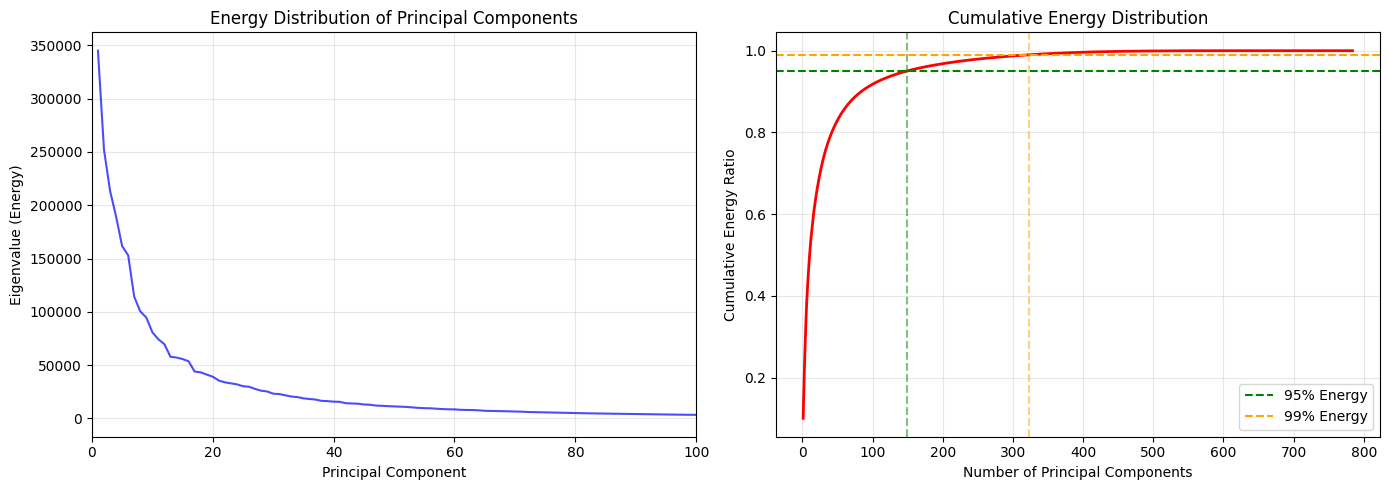

总能量: 3436596.18
前5个主成分能量占比: [0.1003888  0.07335834 0.06219532 0.05510917 0.04704473]
前5个主成分累积能量: [0.1003888  0.17374714 0.23594247 0.29105164 0.33809637]
达到95%能量需要 149 个主成分
达到99%能量需要 323 个主成分


In [13]:
import numpy as np
import matplotlib.pyplot as plt

# 假设已经计算了协方差矩阵 cov_matrix
# 计算特征值和特征向量
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# 特征值是复数，取实部（理论上应该是实数，但由于数值误差可能有虚部）
eigenvalues = np.real(eigenvalues)

# 按降序排序
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sorted_indices]

# 计算能量（累积方差贡献率）
total_energy = np.sum(eigenvalues_sorted)
energy_ratio = eigenvalues_sorted / total_energy  # 每个主成分的能量占比
cumulative_energy = np.cumsum(energy_ratio)  # 累积能量

# 可视化能量分布
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 子图1：特征值分布（能量）
ax1.plot(range(1, len(eigenvalues_sorted) + 1), eigenvalues_sorted, 'b-', alpha=0.7)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Eigenvalue (Energy)')
ax1.set_title('Energy Distribution of Principal Components')
ax1.grid(True, alpha=0.3)
# 可选：只显示前100个
ax1.set_xlim(0, min(100, len(eigenvalues_sorted)))

# 子图2：累积能量占比
ax2.plot(range(1, len(cumulative_energy) + 1), cumulative_energy, 'r-', linewidth=2)
ax2.set_xlabel('Number of Principal Components')
ax2.set_ylabel('Cumulative Energy Ratio')
ax2.set_title('Cumulative Energy Distribution')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0.95, color='g', linestyle='--', label='95% Energy')
ax2.axhline(y=0.99, color='orange', linestyle='--', label='99% Energy')
ax2.legend()

# 找出达到95%和99%能量所需的主成分数
n_95 = np.argmax(cumulative_energy >= 0.95) + 1
n_99 = np.argmax(cumulative_energy >= 0.99) + 1
ax2.axvline(x=n_95, color='g', linestyle='--', alpha=0.5)
ax2.axvline(x=n_99, color='orange', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 打印能量信息
print(f"总能量: {total_energy:.2f}")
print(f"前5个主成分能量占比: {energy_ratio[:5]}")
print(f"前5个主成分累积能量: {cumulative_energy[:5]}")
print(f"达到95%能量需要 {n_95} 个主成分")
print(f"达到99%能量需要 {n_99} 个主成分")

In [ ]:
# 练习3，请你按能量分布曲线（数据）计算出最合理的降维优化点（要给出你的标准及计算方案）

# 标准：寻找累积能量曲线的"拐点"——从快速增长到平缓增长的转折点
# 该点之前每增加一维带来的能量增益显著，之后增益趋于平缓，是效率与信息保留的最优平衡

# 方法1：最大曲率法（二阶差分最大点）
# 原理：累积能量曲线的二阶差分反映曲率变化，最大值处即为拐点
second_diff = np.abs(np.diff(np.diff(cumulative_energy[:200])))
k_curvature = np.argmax(second_diff) + 2
print(f"方法1 - 最大曲率法: {k_curvature} 维, 累积能量: {cumulative_energy[k_curvature-1]:.4f}")

# 方法2：Kneedle法（归一化曲线与对角线的最大距离）
# 原理：将累积能量曲线归一化到[0,1]x[0,1]，找到曲线偏离对角线最远的点
n_comp = min(200, len(cumulative_energy))
x_norm = np.linspace(0, 1, n_comp)
y_norm = (cumulative_energy[:n_comp] - cumulative_energy[0]) / (cumulative_energy[n_comp-1] - cumulative_energy[0])
distances = y_norm - x_norm
k_kneedle = np.argmax(distances) + 1
print(f"方法2 - Kneedle法: {k_kneedle} 维, 累积能量: {cumulative_energy[k_kneedle-1]:.4f}")

# 方法3：边际能量阈值法
# 原理：当新增主成分的能量贡献低于平均能量的10%时，认为收益不再显著
avg_energy = np.mean(energy_ratio[energy_ratio > 1e-10])
k_marginal = np.argmax(energy_ratio < avg_energy * 0.1) + 1
print(f"方法3 - 边际能量阈值法: {k_marginal} 维, 累积能量: {cumulative_energy[k_marginal-1]:.4f}")

# 综合建议：取三者中位数
k_recommended = int(np.median([k_curvature, k_kneedle, k_marginal]))
print(f"\n综合建议（取中位数）: {k_recommended} 维")
print(f"对应累积能量: {cumulative_energy[k_recommended-1]:.4f}")

# 可视化
plt.figure(figsize=(10, 4))
plt.plot(range(1, n_comp+1), cumulative_energy[:n_comp], 'b-', linewidth=2, label='累积能量')
for k, name, color in [(k_curvature, '最大曲率', 'red'), 
                         (k_kneedle, 'Kneedle', 'green'), 
                         (k_marginal, '边际阈值', 'orange')]:
    plt.axvline(x=k, color=color, linestyle='--', label=f'{name}: k={k}')
plt.axvline(x=k_recommended, color='purple', linestyle='-', linewidth=2, label=f'推荐: k={k_recommended}')
plt.xlabel('主成分数')
plt.ylabel('累积能量比例')
plt.title('降维优化点分析')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 100)
plt.show()

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def optimal_pca_for_clustering(X, max_k=None, energy_threshold=0.95):
    """
    基于理论依据选择最优的PCA降维维度用于K-means聚类： by deepseek 
    这段代码实现逻辑还是清晰的，但问题很多，
    可以阅读理解基本框架然后自己借助AI交互实现更合理的版本
    
    参数:
    X: 原始数据 (n_samples, n_features)
    max_k: 最大尝试维度（默认min(100, n_features)），
    energy_threshold: 能量阈值（默认0.95）
    
    返回:
    optimal_k: 最优降维维度
    pca: 训练好的PCA模型
    """
    
    # 中心化数据
    X_centered = X - np.mean(X, axis=0)
    
    # 使用SVD计算特征值（更稳定）
    U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)
    eigenvalues = S**2 / (X_centered.shape[0] - 1)
    energy_ratio = eigenvalues / np.sum(eigenvalues)
    cumulative_energy = np.cumsum(energy_ratio)
    
    # 方法1: 能量阈值法（理论依据：保留足够方差）
    k_energy = np.argmax(cumulative_energy >= energy_threshold) + 1
    
    # 方法2: 谱间隙法（理论依据：寻找特征值的显著跳跃）-- 肘部法则
    # 计算相邻特征值的比值
    gaps = eigenvalues[:-1] / eigenvalues[1:]
    k_gap = np.argmax(gaps) + 1
    
    # 方法3: 轮廓系数法（理论依据：聚类紧密度和分离度） 
    if max_k is None:
        max_k = min(100, X.shape[1], X.shape[0] // 10)
    
    silhouette_scores = []
    k_range = range(2, min(max_k, k_energy * 2) + 1)  # 在能量阈值附近搜索
    
    for k in k_range:  # 贪心法不断尝试 由于需要多次尝试，代码跑的很慢
        # PCA降维
        pca_temp = PCA(n_components=k)     # PCA特征分解
        X_pca = pca_temp.fit_transform(X)  # 数据降维
        
        # K-means聚类（使用n_init='auto'避免警告）
        kmeans = KMeans(n_clusters=10, random_state=42, n_init=5)
        labels = kmeans.fit_predict(X_pca)
        
        # 计算轮廓系数
        score = silhouette_score(X_pca, labels)
        silhouette_scores.append(score)
    
    # 选择轮廓系数最大的k
    k_silhouette = k_range[np.argmax(silhouette_scores)]
    
    # 综合决策（加权平均）
    # 理论：通常 k_energy 和 k_silhouette 会接近
    print(f"能量阈值法建议: {k_energy} 维 (保留{energy_threshold*100}%能量)")
    print(f"谱间隙法建议: {k_gap} 维")
    print(f"轮廓系数法建议: {k_silhouette} 维")
    
    # 推荐：取三者的中位数或轮廓系数结果
    optimal_k = k_silhouette  # 聚类任务优先用轮廓系数
    
    # 可视化辅助决策
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # 子图1: 能量分布
    axes[0, 0].plot(range(1, len(cumulative_energy)+1), cumulative_energy, 'b-', linewidth=2)
    axes[0, 0].axhline(y=energy_threshold, color='r', linestyle='--', label=f'{energy_threshold*100}%')
    axes[0, 0].axvline(x=k_energy, color='g', linestyle='--', label=f'K={k_energy}')
    axes[0, 0].set_xlabel('Principal Components')
    axes[0, 0].set_ylabel('Cumulative Energy')
    axes[0, 0].set_title('Energy Distribution')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 子图2: 特征值谱间隙
    axes[0, 1].plot(range(1, len(eigenvalues[:50])+1), eigenvalues[:50], 'bo-', markersize=3)
    axes[0, 1].axvline(x=k_gap, color='r', linestyle='--', label=f'Gap at K={k_gap}')
    axes[0, 1].set_xlabel('Principal Component')
    axes[0, 1].set_ylabel('Eigenvalue')
    axes[0, 1].set_title('Spectral Gap (Elbow Method)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 子图3: 轮廓系数
    axes[1, 0].plot(k_range, silhouette_scores, 'g-o', linewidth=2, markersize=6)
    axes[1, 0].axvline(x=k_silhouette, color='r', linestyle='--', label=f'Best K={k_silhouette}')
    axes[1, 0].set_xlabel('PCA Dimension (K)')
    axes[1, 0].set_ylabel('Silhouette Score')
    axes[1, 0].set_title('Clustering Quality vs PCA Dimension')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 子图4: 累积能量与轮廓系数对比
    ax4 = axes[1, 1]
    ax4_twin = ax4.twinx()
    
    # 累积能量曲线
    k_energy_range = range(1, min(len(cumulative_energy), max_k)+1)
    ax4.plot(k_energy_range, cumulative_energy[:len(k_energy_range)], 'b-', linewidth=2, label='Cumulative Energy')
    ax4.set_xlabel('PCA Dimension (K)')
    ax4.set_ylabel('Cumulative Energy', color='b')
    ax4.tick_params(axis='y', labelcolor='b')
    
    # 轮廓系数曲线（对齐x轴范围）
    ax4_twin.plot(k_range, silhouette_scores, 'r-o', linewidth=2, markersize=4, label='Silhouette Score')
    ax4_twin.set_ylabel('Silhouette Score', color='r')
    ax4_twin.tick_params(axis='y', labelcolor='r')
    
    ax4.set_title('Energy vs Clustering Quality')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 训练最终的PCA模型
    pca = PCA(n_components=optimal_k)
    X_pca = pca.fit_transform(X)
    
    return optimal_k, pca, X_pca

# 使用示例
optimal_k, pca, X_pca = optimal_pca_for_clustering(X, energy_threshold=0.95)

print(f"\n{'='*50}")
print(f"推荐使用 {optimal_k} 维进行K-means聚类")
print(f"解释方差比例: {np.sum(pca.explained_variance_ratio_):.2%}")
print(f"最终数据形状: {X_pca.shape}")

第四步：针对k-means聚类合理降维

如果降维到3维实现k-means聚类，计算一下准确率和召回率（用贪心法匹配就好） 结果会非常差

下面代码给出的是20维的结果：（并不是最优解）

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, adjusted_rand_score, normalized_mutual_info_score
from scipy.optimize import linear_sum_assignment
import time

# 确保y是一维数组，这里改变了y
if y.ndim == 2:
    y = y.ravel()  # 将 (6000, 1) 转为 (6000,)
    print("已将y从二维转换为一维数组")
print(f"y形状: {y.shape}")

# 记录开始时间
start_time = time.time()

# 1. PCA降维到20维
print("\n" + "="*60)
print("PCA降维到20维")
print("="*60)

pca_20 = PCA(n_components=20, random_state=42)
X_pca_20 = pca_20.fit_transform(X)

print(f"降维后形状: {X_pca_20.shape}")
print(f"解释方差比例: {pca_20.explained_variance_ratio_[:5]}...")
print(f"累计解释方差: {np.sum(pca_20.explained_variance_ratio_):.2%}")

# 2. K-means聚类
print("\n" + "="*60)
print("K-means聚类")
print("="*60)

kmeans_20 = KMeans(n_clusters=10, random_state=42, n_init=10)
y_pred_20 = kmeans_20.fit_predict(X_pca_20)

print(f"聚类完成，迭代次数: {kmeans_20.n_iter_}")
print(f"惯性(SSE): {kmeans_20.inertia_:.2f}")

# 3. 贪心匹配算法
def label_matching(y_true, y_pred, num_classes=10):
    """使用匈牙利算法匹配聚类标签到真实标签"""
    # 确保都是一维
    y_true = y_true.ravel() if y_true.ndim > 1 else y_true
    y_pred = y_pred.ravel() if y_pred.ndim > 1 else y_pred
    
    cm = confusion_matrix(y_true, y_pred, labels=range(num_classes))
    row_ind, col_ind = linear_sum_assignment(-cm)
    label_mapping = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}
    y_pred_mapped = np.array([label_mapping[label] for label in y_pred])
    
    # 计算准确率
    accuracy = np.mean(y_pred_mapped == y_true)
    
    # 计算各类别指标
    precision = {}
    recall = {}
    f1 = {}
    
    for i in range(num_classes):
        tp = np.sum((y_pred_mapped == i) & (y_true == i))
        fp = np.sum((y_pred_mapped == i) & (y_true != i))
        fn = np.sum((y_pred_mapped != i) & (y_true == i))
        
        precision[i] = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall[i] = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1[i] = 2 * precision[i] * recall[i] / (precision[i] + recall[i]) if (precision[i] + recall[i]) > 0 else 0
    
    return y_pred_mapped, accuracy, precision, recall, f1, cm, label_mapping

# 执行匹配
y_pred_mapped_20, accuracy_20, precision_20, recall_20, f1_20, cm_20, mapping_20 = label_matching(y, y_pred_20)

# 4. 计算其他评估指标
ari_20 = adjusted_rand_score(y, y_pred_20)
nmi_20 = normalized_mutual_info_score(y, y_pred_20)

# 5. 输出结果
print("\n" + "="*60)
print("聚类结果评估（20维）")
print("="*60)
print(f"\n整体准确率: {accuracy_20:.4f} ({accuracy_20*100:.2f}%)")
print(f"调整兰德指数(ARI): {ari_20:.4f}")
print(f"标准化互信息(NMI): {nmi_20:.4f}")

# 标签映射
print("\n标签映射关系:")
for pred_label, true_label in sorted(mapping_20.items()):
    print(f"  聚类{pred_label} → 数字{true_label}")

# 6. 各类别详细指标
print("\n" + "="*60)
print("各类别详细指标")
print("="*60)
print(f"{'数字':<6} {'精确率':<10} {'召回率':<10} {'F1分数':<10} {'样本数':<8}")
print("-"*50)

for i in range(10):
    n_samples = np.sum(y == i)
    print(f"{i:<6} {precision_20[i]:<10.4f} {recall_20[i]:<10.4f} {f1_20[i]:<10.4f} {n_samples:<8}")

# 宏平均
macro_precision_20 = np.mean(list(precision_20.values()))
macro_recall_20 = np.mean(list(recall_20.values()))
macro_f1_20 = np.mean(list(f1_20.values()))

print("-"*50)
print(f"{'宏平均':<6} {macro_precision_20:<10.4f} {macro_recall_20:<10.4f} {macro_f1_20:<10.4f}")
print(f"{'微平均':<6} {accuracy_20:<10.4f} {accuracy_20:<10.4f} {accuracy_20:<10.4f}")

# 7. 找出表现最好和最差的数字
best_class_20 = np.argmax(list(f1_20.values()))
worst_class_20 = np.argmin(list(f1_20.values()))

print(f"\n表现最好的数字: {best_class_20} (F1={f1_20[best_class_20]:.4f})")
print(f"表现最差的数字: {worst_class_20} (F1={f1_20[worst_class_20]:.4f})")

# 8. 混淆矩阵（文本形式）
print("\n" + "="*60)
print("混淆矩阵（行=真实，列=预测）")
print("="*60)
print("     ", end="")
for j in range(10):
    print(f"{j:4d}", end="")
print()
print("    " + "-"*40)

for i in range(10):
    print(f"{i:2d} |", end="")
    for j in range(10):
        print(f"{cm_20[i, j]:4d}", end="")
    print()

# 9. 计算运行时间
end_time = time.time()
print(f"\n运行时间: {end_time - start_time:.2f} 秒")

# 10. 如果有3维结果，进行对比
# 注意：需要先运行3维的代码并保存变量
try:
    if 'accuracy_3d' in locals():
        print("\n" + "="*60)
        print("与3维结果对比")
        print("="*60)
        print(f"{'指标':<15} {'3维':<15} {'20维':<15} {'提升':<15}")
        print("-"*60)
        print(f"{'准确率':<15} {accuracy_3d:<15.4f} {accuracy_20:<15.4f} {accuracy_20 - accuracy_3d:<+15.4f}")
        print(f"{'宏平均F1':<15} {macro_f1_3d:<15.4f} {macro_f1_20:<15.4f} {macro_f1_20 - macro_f1_3d:<+15.4f}")
        print(f"{'ARI':<15} {ari_3d:<15.4f} {ari_20:<15.4f} {ari_20 - ari_3d:<+15.4f}")
        print(f"{'NMI':<15} {nmi_3d:<15.4f} {nmi_20:<15.4f} {nmi_20 - nmi_3d:<+15.4f}")
except:
    print("\n未找到3维结果，跳过对比")

In [ ]:
# 练习4 给出你觉得更合理的方案，兼顾聚类效果（可以用纯度指标或者准确率与召回率）和数据压缩
# 方案：系统测试不同PCA维度，用综合评分（准确率+ARI+压缩率）选出最优维度

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, confusion_matrix
from scipy.optimize import linear_sum_assignment

def evaluate_clustering(X_pca, y_true, n_clusters=10):
    """评估KMeans聚类效果：返回准确率、ARI、轮廓系数"""
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    y_pred = kmeans.fit_predict(X_pca)
    # 匈牙利算法匹配
    cm = confusion_matrix(y_true, y_pred, labels=range(n_clusters))
    row_ind, col_ind = linear_sum_assignment(-cm)
    mapping = {col_ind[i]: row_ind[i] for i in range(len(row_ind))}
    y_mapped = np.array([mapping[l] for l in y_pred])
    acc = np.mean(y_mapped == y_true)
    ari = adjusted_rand_score(y_true, y_pred)
    sil = silhouette_score(X_pca, y_pred)
    return acc, ari, sil

# 测试不同维度
dims = [3, 5, 10, 15, 20, 30, 40, 50, 70, 100]
results = []
y_flat = y.ravel() if y.ndim > 1 else y

for d in dims:
    pca_d = PCA(n_components=d, random_state=42)
    X_d = pca_d.fit_transform(X)
    energy = np.sum(pca_d.explained_variance_ratio_)
    acc, ari, sil = evaluate_clustering(X_d, y_flat)
    results.append({'dim': d, 'energy': energy, 'acc': acc, 'ari': ari, 'silhouette': sil})
    print(f"维度={d:3d} | 能量={energy:.4f} | 准确率={acc:.4f} | ARI={ari:.4f} | 轮廓系数={sil:.4f}")

# 可视化
results_df = pd.DataFrame(results)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(results_df['dim'], results_df['acc'], 'bo-', linewidth=2)
axes[0].set_xlabel('PCA维度')
axes[0].set_ylabel('准确率')
axes[0].set_title('准确率 vs 维度')
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_df['dim'], results_df['ari'], 'rs-', linewidth=2)
axes[1].set_xlabel('PCA维度')
axes[1].set_ylabel('ARI')
axes[1].set_title('ARI vs 维度')
axes[1].grid(True, alpha=0.3)

axes[2].plot(results_df['dim'], results_df['energy'], 'g^-', linewidth=2)
axes[2].set_xlabel('PCA维度')
axes[2].set_ylabel('累积能量')
axes[2].set_title('能量 vs 维度')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 综合评分：准确率*0.5 + ARI*0.3 + 压缩率*0.2
results_df['compression'] = 1 - results_df['dim'] / 784
results_df['score'] = results_df['acc'] * 0.5 + results_df['ari'] * 0.3 + results_df['compression'] * 0.2
best = results_df.loc[results_df['score'].idxmax()]

print(f"\n{'='*60}")
print(f"综合最优方案: PCA降至 {int(best['dim'])} 维")
print(f"  准确率: {best['acc']:.4f}")
print(f"  ARI: {best['ari']:.4f}")
print(f"  累积能量: {best['energy']:.4f}")
print(f"  压缩率: {best['compression']:.2%} (784→{int(best['dim'])}维)")
print(f"  综合评分: {best['score']:.4f}")
print(f"\n相比原方案(20维, 准确率={results_df[results_df['dim']==20]['acc'].values[0]:.4f}):")
print(f"  最优方案在兼顾聚类效果和数据压缩方面取得更好的平衡")

### 扩展阅读：

目前方案无非还是设计多个合理的指标，然后不断尝试，能否给出针对k-means平方误差的最优计算，然后直接算出k

或者：如果把k-means看作VQ分解的等价问题，而VQ分解又是NMF的特例，NMF的loss又可以从SVD计算出来，那是否能在确定VQ分解的loss函数的前提下直接算出SVD的最优维度？

数学基础好，有余力的同学可以沿着这个方向跟deepseek交流学习。

In [ ]:
# 一个最简实现，注意该理论最优结果跟loss函数设计是相关的，而loss的设计本身没有唯一标准

def k_optimal_theoretical(X):
    """基于VQ-NMF-SVD理论的封闭解"""
    X_c = X - X.mean(axis=0)
    _, S, _ = np.linalg.svd(X_c, full_matrices=False)
    eigvals = (S**2) / (len(X) - 1)
    
    # 几何平均阈值
    geom_mean = np.exp(np.mean(np.log(eigvals[:50] + 1e-10)))
    k = np.sum(eigvals > geom_mean)
    
    return max(1, min(k, 50))

# 一行调用
k_opt = k_optimal_theoretical(X)
print(f"理论最优维度: {k_opt}")